In [109]:
#Criando a tabela de dados
import pandas as pd

dados = pd.read_csv("C:\\Users\\User\\Desktop\\Data Science\\Machine Learning Supervisionado\\Modelo4\\precos.csv")
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido
0,21801,2000,30941.02,1
1,7843,1998,40557.96,1
2,7109,2006,89627.50,0
3,26823,2015,95276.14,0
4,7935,2014,117384.68,1


# Convertendo as unidades de medida

Como estamos no Brasil, não usamos milhas por ano, usamos quilômetros por ano.

In [110]:
dados["km_por_ano"] = dados["milhas_por_ano"] * 1.60934
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano
0,21801,2000,30941.02,1,35085.22134
1,7843,1998,40557.96,1,12622.05362
2,7109,2006,89627.50,0,11440.79806
3,26823,2015,95276.14,0,43167.32682
4,7935,2014,117384.68,1,12770.11290


# Editando a tabela

é mais prático calcular os quilômetros rodados a partir da idade do carro do que a partir do ano do modelo, para isso foi criado uma coluna nova Idade

In [111]:
from datetime import datetime
dados["idade"] = datetime.today().year - dados["ano_do_modelo"]
dados.head()

,milhas_por_ano,ano_do_modelo,preco,vendido,km_por_ano,idade
0,21801,2000,30941.02,1,35085.22134,25
1,7843,1998,40557.96,1,12622.05362,27
2,7109,2006,89627.50,0,11440.79806,19
3,26823,2015,95276.14,0,43167.32682,10
4,7935,2014,117384.68,1,12770.11290,11


# Removendo as colunas que não serão mais utilizadas

In [112]:
# Removendo as colunas "milhas_por_ano" e "ano_do_modelo"
dados.drop(["milhas_por_ano", "ano_do_modelo"], axis=1, inplace=True)
dados.head()

,preco,vendido,km_por_ano,idade
0,30941.02,1,35085.22134,25
1,40557.96,1,12622.05362,27
2,89627.50,0,11440.79806,19
3,95276.14,0,43167.32682,10
4,117384.68,1,12770.11290,11


# Conferindo a taxa de acerto

O SVC treina no x e no y, com um SEED fixo, roda o StandardScaler, escala, roda o SVC e imprime a acurácia.

In [113]:
x = dados[["preco", "idade", "km_por_ano"]]
y = dados["vendido"]

In [114]:
# quando for import SVC usa modelo = SVC(gamma='auto')
# quando for import LinearSVC usa modelo = LinearSVC()
# Ambos estão fazendo a Transformação na Escala dos Dados

# Rodando o Modelo em SVC

In [115]:
# SVC treina no x e no y, com um SEED fixo, roda o StandardScaler, escala, roda o SVC e imprime a acurácia.
# Resultado: Para prever a venda dos veículos, 7.500 itens no treino, 2.500 itens no teste. 75.92 é a taxa de acerto.
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y,
random_state = SEED,
stratify = y)
print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")


scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)


modelo = SVC(gamma='auto')
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 7500
Testaremos com 2500
A acurácia foi de 75.92%


# Rodando o Modelo em LinearSVC

In [116]:
# Resultado: Com o LinearSVC, a taxa de acerto foi de 69.92. Se comparado ao LinearSVC,o SVC com o gamma alto é um pouco melhor. 

from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 20

raw_treino_x, raw_teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(raw_treino_x)}")
print(f"Testaremos com {len(raw_teste_x)}")


scaler = StandardScaler()
scaler.fit(raw_treino_x)

treino_x = scaler.transform(raw_treino_x)
teste_x = scaler.transform(raw_teste_x)


modelo = LinearSVC()
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 7500
Testaremos com 2500
A acurácia foi de 69.92%


In [117]:
# Total de Veículos Vendidos
len(dados.query("vendido == True"))

5800

In [118]:
# Percentual de Veículos Vendidos
len(dados.query("vendido == True")) / len(dados)

0.58

# Usando o Modelo DummyClassifier

usando com strategy = 'stratified'

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

classificador = DummyClassifier(strategy = 'stratified') 
classificador.fit(raw_treino_x, treino_y)
previsoes = classificador.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia do dummy foi de {acuracia:.2f}%")

A acurácia do dummy foi de 51.68%


usando sem strategy = 'stratified'

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier


Classificador = DummyClassifier()
classificador.fit(raw_treino_x, treino_y)
previsoes = classificador.predict(raw_teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia do dummy foi de {acuracia:.2f}%")

A acurácia do dummy foi de 51.16%


# Criando uma árvore de decisões de classificação

# Usando o Modelo DecisionTreeClassifier

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 20

treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
random_state = SEED,
stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")


#scaler = StandardScaler()  #não recomendado utilizar ele para modelo de arvore de decisão
#scaler.fit(raw_treino_x)  #não recomendado utilizar ele para modelo de arvore de decisão

#treino_x = scaler.transform(raw_treino_x)  #não recomendado utilizar ele para modelo de arvore de decisão
#teste_x = scaler.transform(raw_teste_x)  #não recomendado utilizar ele para modelo de arvore de decisão


modelo = DecisionTreeClassifier(max_depth=3) # ax_depth=3 limita em 3 niveis dos nos de decisão
modelo.fit(treino_x, treino_y)
previsoes = modelo.predict(teste_x)

acuracia = accuracy_score(teste_y, previsoes) * 100
print(f"A acurácia foi de {acuracia:.2f}%")

Treinaremos com 7500
Testaremos com 2500
A acurácia foi de 78.40%


# Montando a visualização da árvore de decisões

De acordo com os valores das variaveis o class exibe Sim para "vai vender" ou Não "Não Vai Vender"

Estas são as decisões que o algoritimo esta tomando para fazer a previsão

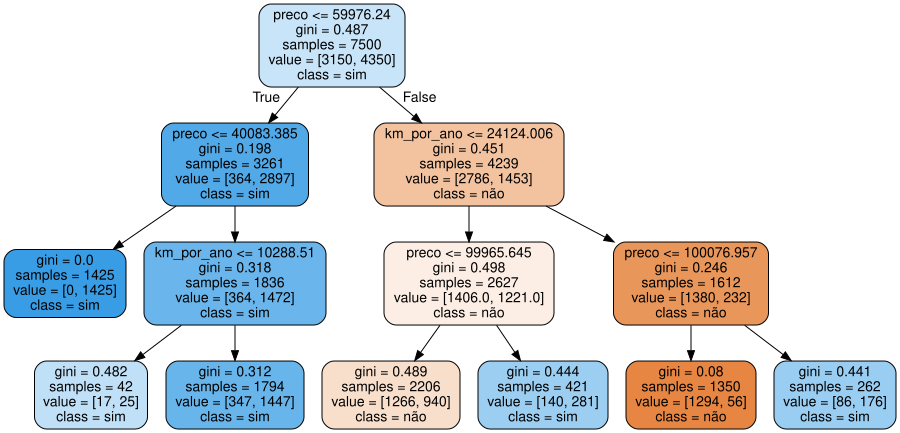

In [122]:
#Quanto mais a cor for azul está indo para a classe 0, quanto mais a cor for laranja está indo para a classe 1
#Treinou com 7500 - samples = amostras
# Values 3150 de um tipo, ou seja do 0 e 4350 de outro tipo, ou seja do 1
from sklearn.tree import export_graphviz
import graphviz

estrutura = export_graphviz(modelo, filled=True, rounded=True, feature_names=x.columns, class_names=["não", "sim"])
grafico = graphviz.Source(estrutura)
grafico

In [123]:
treino_x, teste_x, treino_y, teste_y = train_test_split(x, y,
                                                         random_state = SEED,
                                                         stratify = y)
print(f"Treinaremos com {len(treino_x)}")
print(f"Testaremos com {len(teste_x)}")


# scaler = StandardScaler()
# scaler.fit(raw_treino_x)

# treino_x = scaler.transform(raw_treino_x)
# teste_x = scaler.transform(raw_teste_x)

Treinaremos com 7500
Testaremos com 2500


Se o preço é menor ou igual a 59.976 reais, ele vai para a esquerda, se o preço for menor ou igual a 40.000 reais, ele prevê que vai vender.

Se o preço for menor que 40.000 reais e o quilômetros por ano for menor do que 10.000, vai vender. Se não, também vai vender. Para irmos para a direita, o preço tem que ser maior do que 59.976.

E aí ele vai fazendo as análises, por exemplo, se ele é menor do que 24.000 quilômetros por ano e o preço é maior do que 99.000, então, ele vai vender. Senão, não vai vender.

Essas são as decisões que o algoritmo está tomando para fazer a previsão. 